<a href="https://colab.research.google.com/github/Aya-hassan101/ML_portfolio/blob/main/X_Ray_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#promt : Read bone feature images datasets from kaggle

!pip install kaggle

#Upload your kaggle.json file (contains API Key)
from google.colab import files
files.upload()

#Make directory and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

#Change permission of the file
!chmod 600 ~/.kaggle/kaggle.json

#Download the dataset
!kaggle datasets download bmadushanirodrigo/fracture-multi-region-x-ray-data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 481M/481M [00:03<00:00, 165MB/s]



In [ ]:

!mkdir -p '/content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary'

# Unzip the dataset to the specified directory
!unzip /content/fracture-multi-region-x-ray-data.zip -d '/content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary'

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fract

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile

# Allow Pillow to load truncated images to handle potential corrupted image files
ImageFile.LOAD_TRUNCATED_IMAGES = True

#Define image dimensions and batch size
img_width ,img_height=150,150
batch_size=32

#create image data generatore with data augmentation for training and validation set
train_datagen=ImageDataGenerator()

train_generator=train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train',
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,
                                                  class_mode='binary')

test_generator=train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val',
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,
                                                  class_mode='binary')


validation_generator=train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/Bone_Fracture_Binary/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test',
                                                  target_size=(img_width,img_height),
                                                  batch_size=batch_size,
                                                  class_mode='binary')

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


In [ ]:
train_generator[0][0].shape

(32, 150, 150, 3)

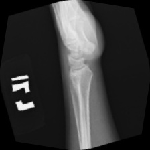

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
cv2_imshow(train_generator[0][0][3])

In [ ]:
callback=keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)
#create the model
model=keras.Sequential()
model.add(keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_width,img_height,3)))
model.add(keras.layers.MaxPooling2D(2,2))
model.add(keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(2,2))
model.add(keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(2,2))
model.add(keras.layers.Flatten())
dropout=keras.layers.Dropout(0.3)
model.add(keras.layers.Dense(256,activation='relu'))
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))
dropout=keras.layers.Dropout(0.5)

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#train the model
model.fit(train_generator,epochs=10,validation_data=validation_generator,callbacks=[callback])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.9099 - loss: 0.6397 - val_accuracy: 0.9447 - val_loss: 0.1315
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.9851 - loss: 0.0472 - val_accuracy: 0.9486 - val_loss: 0.1629
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9925 - loss: 0.0255 - val_accuracy: 0.9664 - val_loss: 0.0953
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.9906 - loss: 0.0313 - val_accuracy: 0.9960 - val_loss: 0.0102
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.9908 - loss: 0.0311 - val_accuracy: 0.9822 - val_loss: 0.0564
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9943 - loss: 0.0211 - val_accuracy: 0.9605 - val_loss: 0.2130
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9969 - loss: 0.0186 - val_accuracy: 0.9545 - val_loss: 0.2672
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9976 - loss: 0.0096 -

In [ ]:
model.evaluate(test_generator)

In [ ]:
model.save("Bone_mode.h5")